Анализ траектории, оценка сходимости.

In [4]:
import numpy as np

rmsd = np.loadtxt("/Users/kirillkiselev/Desktop/Vector/lysozyme_tutorial/rmsd.xvg", comments=("#", "@"))

mid = len(rmsd) // 2

first = rmsd[:mid, 1]
second = rmsd[mid:, 1]

print("0–5 ns:", first.mean(), "+/-", first.std())
print("5–10 ns:", second.mean(), "+/-", second.std())

0–5 ns: 0.10963176279999999 +/- 0.015367025857082956
5–10 ns: 0.1052807373253493 +/- 0.010167357539912483


(129, 2)
[[ 1.      0.0723]
 [ 2.      0.0601]
 [ 3.      0.0492]
 [ 4.      0.0538]
 [ 5.      0.0512]
 [ 6.      0.0477]
 [ 7.      0.0482]
 [ 8.      0.0428]
 [ 9.      0.043 ]
 [10.      0.0473]]


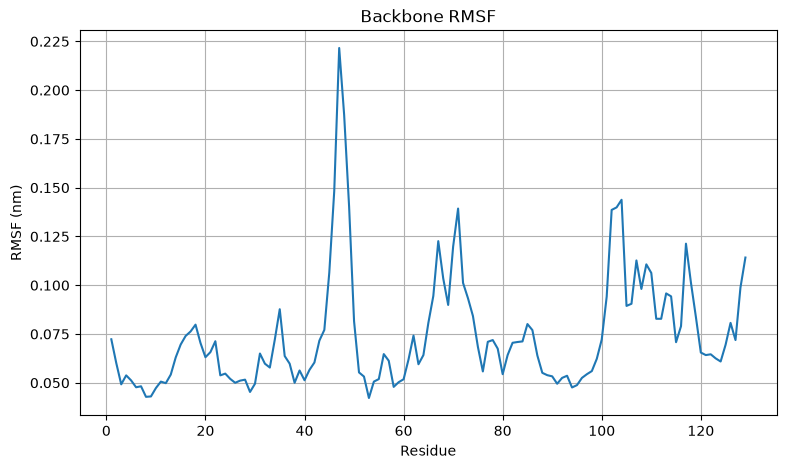

In [5]:
import numpy as np
import matplotlib.pyplot as plt

rmsf = np.loadtxt(
    "/Users/kirillkiselev/Desktop/Vector/lysozyme_tutorial/rmsf.xvg",
    comments=("#", "@")
)

print(rmsf.shape)
print(rmsf[:10])

plt.figure(figsize=(9, 5))
plt.plot(rmsf[:, 0], rmsf[:, 1])

plt.xlabel("Residue")
plt.ylabel("RMSF (nm)")
plt.title("Backbone RMSF")
plt.grid()

plt.show()

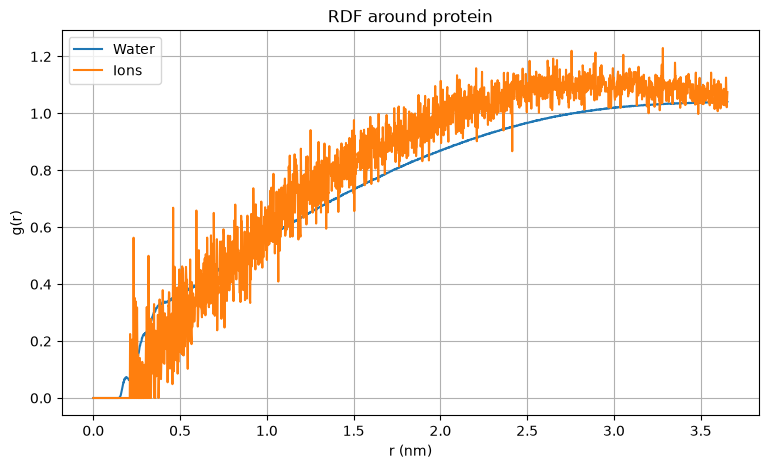

In [6]:
import numpy as np
import matplotlib.pyplot as plt

rdf_water = np.loadtxt(
    "/Users/kirillkiselev/Desktop/Vector/lysozyme_tutorial/rdf_water.xvg",
    comments=("#", "@")
)

rdf_ions = np.loadtxt(
    "/Users/kirillkiselev/Desktop/Vector/lysozyme_tutorial/rdf_ions.xvg",
    comments=("#", "@")
)

plt.figure(figsize=(9, 5))

plt.plot(rdf_water[:, 0], rdf_water[:, 1], label="Water")
plt.plot(rdf_ions[:, 0], rdf_ions[:, 1], label="Ions")

plt.xlabel("r (nm)")
plt.ylabel("g(r)")
plt.title("RDF around protein")
plt.legend()
plt.grid()

plt.show()

In [7]:
values = rmsd[:, 1]

def block_average(values, block_size):
    n_blocks = len(values) // block_size
    data = values[:n_blocks * block_size]
    blocks = data.reshape(n_blocks, block_size)

    block_means = blocks.mean(axis=1)

    mean = block_means.mean()
    error = block_means.std(ddof=1) / np.sqrt(n_blocks)

    return mean, error


for block_size in [5, 10, 20, 50, 100]:
    mean, error = block_average(values, block_size)

    print(
        f"Block size {block_size:3d}: "
        f"mean = {mean:.4f} nm, "
        f"error = {error:.4f} nm"
    )

Block size   5: mean = 0.1075 nm, error = 0.0008 nm
Block size  10: mean = 0.1075 nm, error = 0.0010 nm
Block size  20: mean = 0.1075 nm, error = 0.0013 nm
Block size  50: mean = 0.1075 nm, error = 0.0019 nm
Block size 100: mean = 0.1075 nm, error = 0.0020 nm


RMSF
RMSF показывает подвижность отдельных аминокислотных остатков относительно их среднего положения за всю траекторию. Для большинства остатков значения остаются в диапазоне 0.04–0.08 nm, что говорит о достаточно стабильном остове белка. При этом есть несколько более подвижных участков. Наиболее заметный пик наблюдается в области 45–50-го остатка, где RMSF достигает около 0.22 nm. Также повышенная подвижность видна в областях 65–75 и 100–120 остатков.


RDF
RDF, или radial distribution function, показывает, как вода и ионы распределены по расстоянию относительно белка. На малых расстояниях значение g(r) близко к нулю, потому что частицы не могут находиться внутри белка. По мере удаления от поверхности белка g(r) растет и постепенно приближается к 1, что соответствует переходу к более равномерному распределению в объеме раствора.

Для воды кривая получается более гладкой из-за большого числа молекул воды. Для ионов наблюдаются более сильные флуктуации, что связано с тем, что в системе было всего несколько ионов, поэтому статистика для них заметно хуже. На больших расстояниях обе кривые стремятся к значениям около 1, что соответствует объемному распределению растворителя и ионов вдали от белка.


Сходимость
Для оценки сходимости траектория была разделена на две половины. Средний RMSD в первой половине составил 0.1096 nm, а во второй — 0.1053 nm. Эти значения близки, при этом разброс во второй половине меньше. Сильного систематического дрейфа структуры на второй половине траектории не наблюдается.

Симуляция сходится, когда основные наблюдаемые характеристики системы перестают меняться со временем и варьируются около стабильных средних значений.

При блок усреднении оценка ошибки RMSD увеличивалась от 0.0008 до 0.0020 nm с ростом размера блока.
На интервале 10 ns основные структурные характеристики ведут себя достаточно стабильно. Одной траектории недостаточно, чтобы строго утверждать полную сходимость системы. Для более надежного вывода обычно используют более длинные траектории и несколько независимых запусков с разными начальными скоростями.